In [2]:
import pandas as pd
import numpy as np


In [5]:
import os

if os.path.exists("../data/processed/X_raw.npy"):
    print("Ucitavam vec obradjene podatke...")
    X = np.load("../data/processed/X_raw.npy")
else:
    print("Učitavam raw podatke...")
    data = pd.read_csv("../data/raw/GSE115469_Data.csv", index_col=0)
    X = data.to_numpy(dtype=np.float32)
    del data

Ucitavam vec obradjene podatke...


In [7]:
X = X.T
print(X.shape)

(8444, 20007)


In [9]:
np.save("../data/processed/X_raw.npy", X)

In [10]:
X = np.load("../data/processed/X_raw.npy")

In [11]:
X[:5]

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.31475955, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], dtype=float32)

In [13]:
variances = np.var(X, axis=0)
k = 3000
top_genes = np.argsort(variances)[-k:]

X = X[:, top_genes]

print(X.shape)


(8444, 3000)


In [14]:
from sklearn.preprocessing import StandardScaler   
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)
del X

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled).astype(np.float32)

print(X_pca.shape)

(8444, 50)


In [17]:
pca.explained_variance_ratio_.sum()

0.2571075

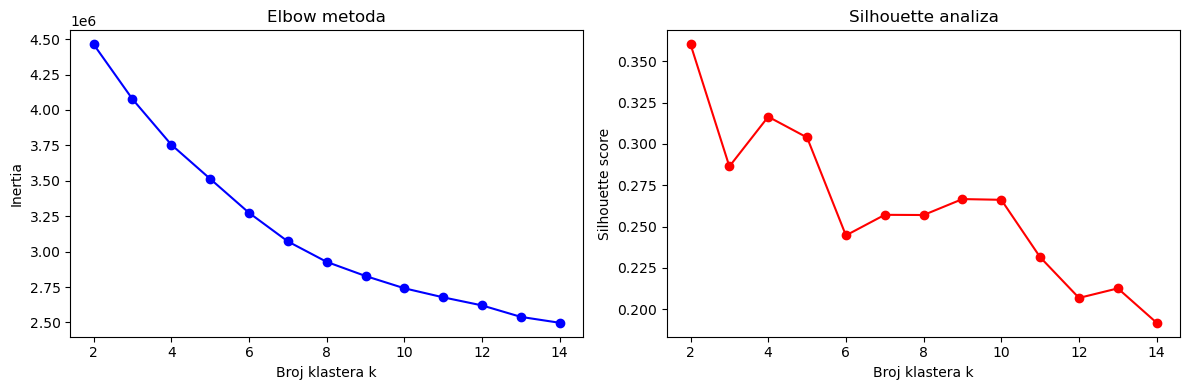

In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from matplotlib import pyplot as plt

inertias = []
silhouettes = []
K_range = range(2, 15)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels, sample_size=2000))


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel("Broj klastera k")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow metoda")

ax2.plot(K_range, silhouettes, 'ro-')
ax2.set_xlabel("Broj klastera k")
ax2.set_ylabel("Silhouette score")
ax2.set_title("Silhouette analiza")

plt.tight_layout()
plt.show()

In [19]:
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_pca)

np.save("../data/processed/cluster_labels.npy", cluster_labels)

/home/bogdan/.local/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


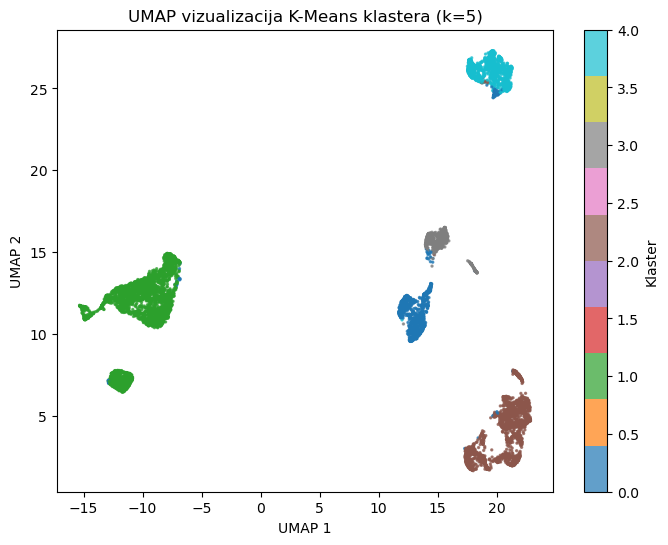

In [20]:
import umap

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_pca)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], 
                      c=cluster_labels, cmap='tab10', s=2, alpha=0.7)
plt.colorbar(scatter, label='Klaster')
plt.title('UMAP vizualizacija K-Means klastera (k=5)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

np.save("../data/processedX_umap.npy", X_umap)